In [33]:
pip install minisom

In [34]:
pip install optuna

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import optuna
from minisom import MiniSom
pd.set_option('display.max_columns', None)
from sklearn.metrics import silhouette_score

In [36]:
data = pd.read_excel(r'/content/scoring.xlsx')
data

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0xd40,3,23.0,12,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,3,809.98,26.822620,1,49.574949,80.415295,3,312.494089,0
1,CUS_0xd40,2,23.0,12,19114.12,NaN,3,4,3,4.0,-1,NaN,11.27,4.0,1,809.98,31.944960,1,49.574949,118.280222,4,284.629162,0
2,CUS_0xd40,6,-500.0,12,19114.12,NaN,3,4,3,4.0,3,7.0,NaN,4.0,1,809.98,28.609352,1,49.574949,81.699521,5,331.209863,0
3,CUS_0xd40,0,23.0,12,19114.12,NaN,3,4,3,4.0,5,4.0,6.27,4.0,1,809.98,31.377862,1,49.574949,199.458074,6,223.451310,0
4,CUS_0xd40,7,23.0,12,19114.12,1824.843333,3,4,3,4.0,6,NaN,11.27,4.0,1,809.98,24.797347,1,49.574949,41.420153,2,341.489231,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0x942c,0,25.0,9,39628.99,3359.415833,4,6,7,2.0,23,7.0,11.50,3.0,3,502.38,34.663572,1,35.104023,60.971333,1,479.866228,1
99996,CUS_0x942c,7,25.0,9,39628.99,3359.415833,4,6,7,2.0,18,7.0,11.50,3.0,3,502.38,40.565631,1,35.104023,54.185950,2,496.651610,1
99997,CUS_0x942c,5,25.0,9,39628.99,3359.415833,4,6,5729,2.0,27,6.0,11.50,3.0,1,502.38,41.255522,1,35.104023,24.028477,1,516.809083,1
99998,CUS_0x942c,4,25.0,9,39628.99,3359.415833,4,6,7,2.0,20,NaN,11.50,3.0,1,502.38,33.638208,1,35.104023,251.672582,4,319.164979,0


In [37]:
data.describe(include='all')

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000.000000,95061.000000,100000.000000,1.000000e+05,84998.000000,100000.000000,100000.00000,100000.000000,95215.000000,100000.000000,90254.000000,97909.000000,98035.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,95521.000000,100000.000000,9.880000e+04,100000.000000
unique,12500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUS_0x942c,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.500000,110.934505,7.523380,1.764157e+05,4194.170850,17.091280,22.47443,72.466040,2.780339,21.068780,31.033051,10.465678,27.754251,1.578800,1426.220376,32.285173,1.403190,1403.118217,637.412998,3.469040,3.036437e+22,0.289980
std,NaN,2.291299,689.407864,4.640296,1.429618e+06,3183.686167,117.404834,129.05741,466.422621,62.500940,14.860104,226.955758,6.670732,193.177339,1.013647,1155.129026,5.116875,0.693378,8306.041270,2043.319327,2.035471,3.181295e+24,0.453755
min,NaN,0.000000,-500.000000,0.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,0.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.000000,0.000000,7.759665e-03,0.000000
25%,NaN,1.750000,24.000000,4.000000,1.945750e+04,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.350000,3.000000,1.000000,566.072500,28.052567,1.000000,30.306660,74.534002,2.000000,2.701145e+02,0.000000
50%,NaN,3.500000,33.000000,7.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,2.000000,1166.155000,32.305784,2.000000,69.249473,135.925682,3.000000,3.367423e+02,0.000000
75%,NaN,5.250000,42.000000,12.000000,7.279092e+04,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.870000,9.000000,2.000000,1945.962500,36.496663,2.000000,161.224249,265.731733,6.000000,4.703321e+02,1.000000


In [38]:
data.drop(data[['Customer_ID']],axis=1, inplace=True)

##  MISSING VALUE IMPUTATION

In [39]:
data.isnull().sum()

,0
Month,0
Age,4939
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,4785
Delay_from_due_date,0


## Outlier Treatment

In [40]:
for i in data.columns:
  if data[i].dtypes == 'object':
    data[i] = data[i].fillna(data[i].mode()[0])
  else:
    data[i]= data[i].fillna(data[i].mean())

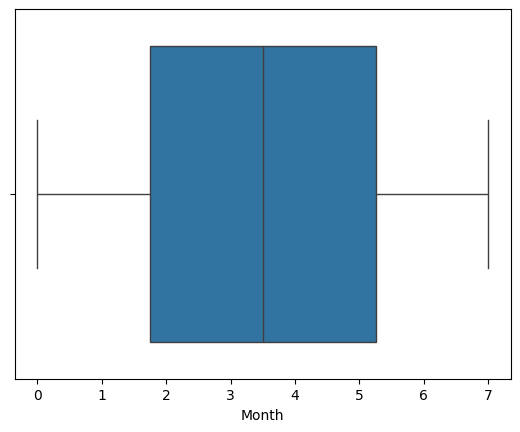

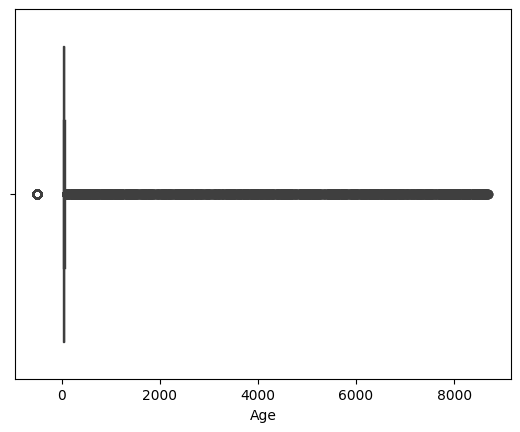

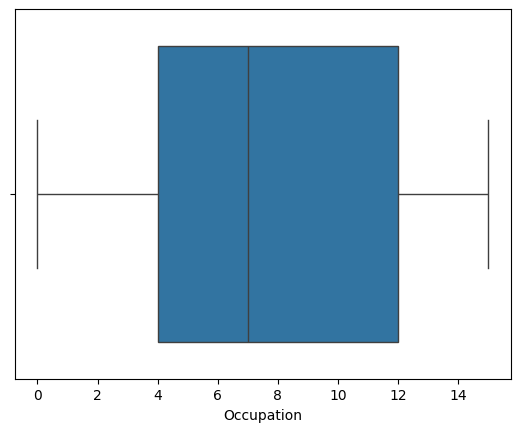

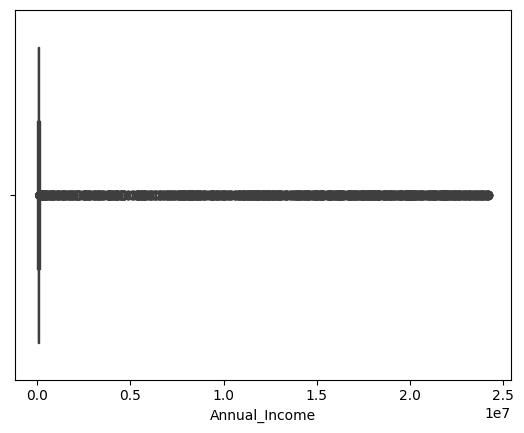

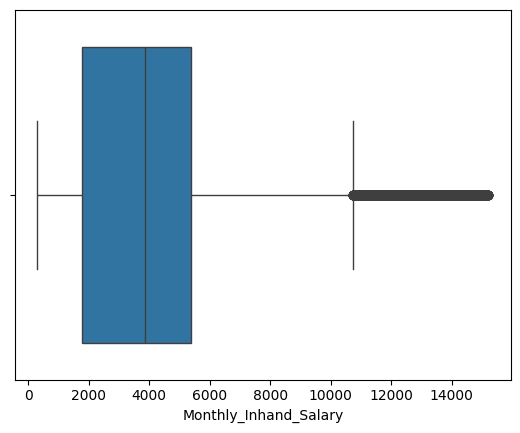

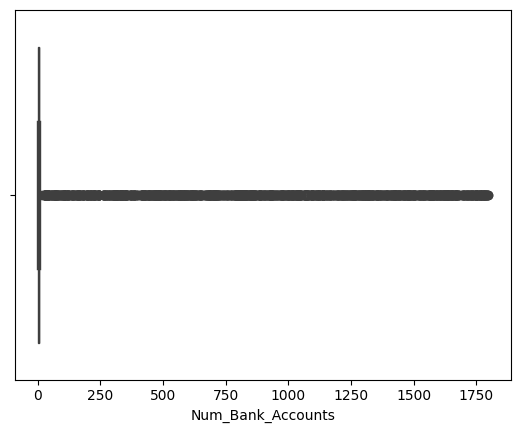

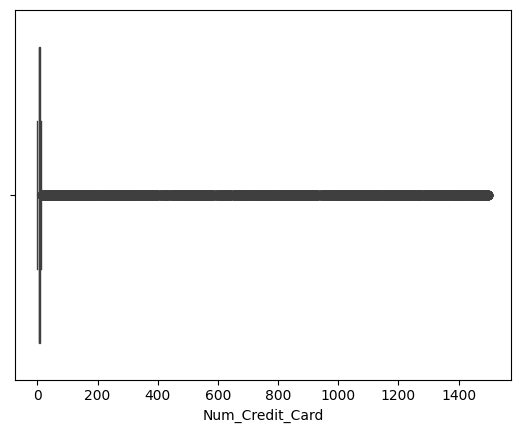

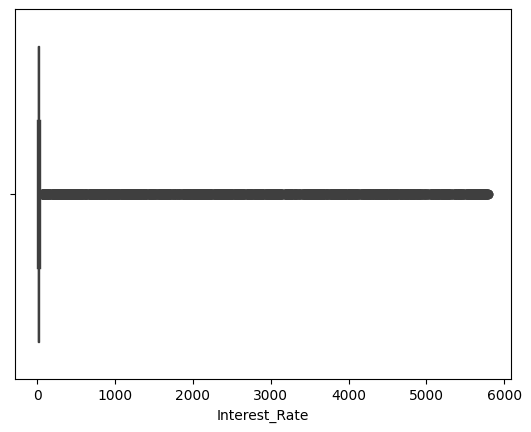

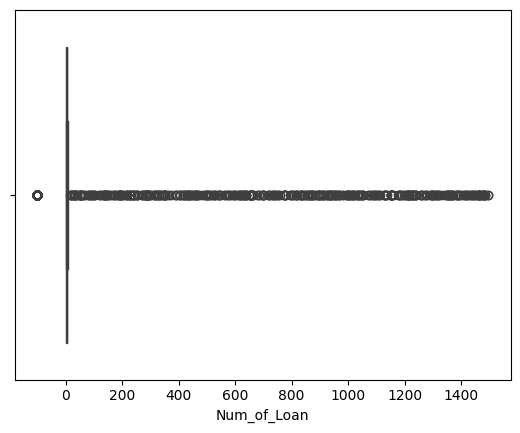

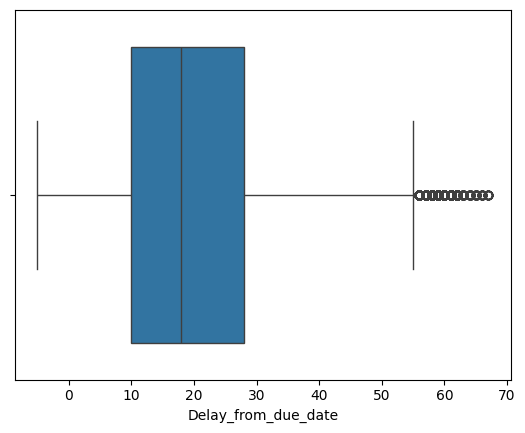

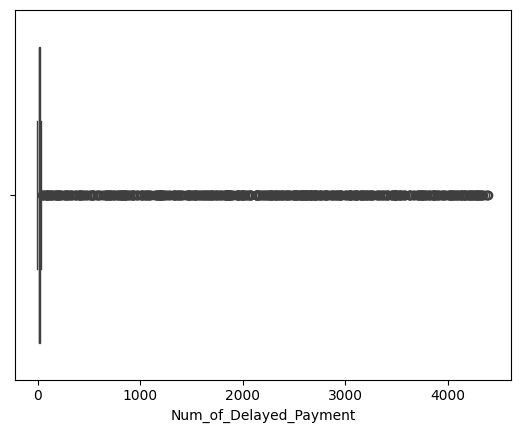

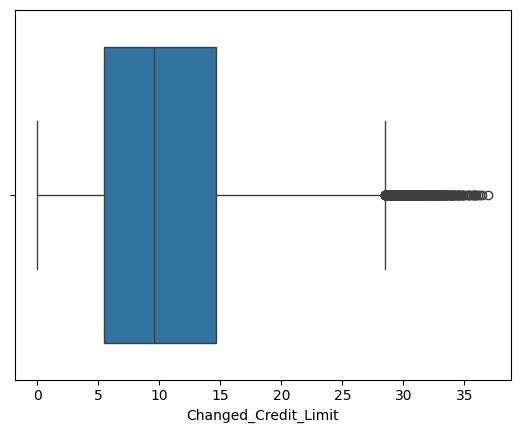

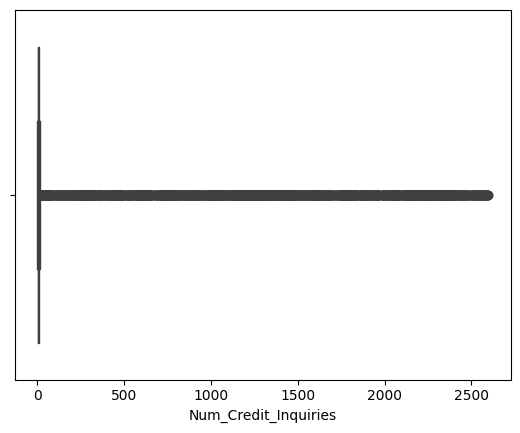

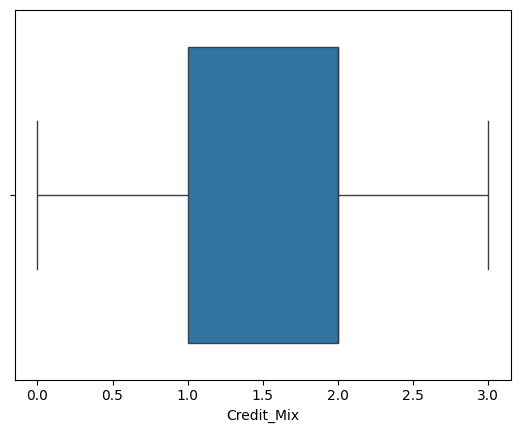

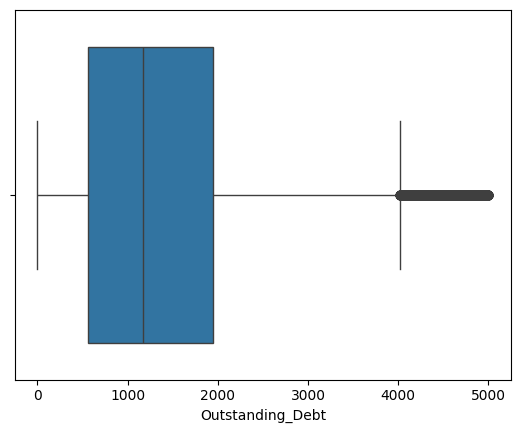

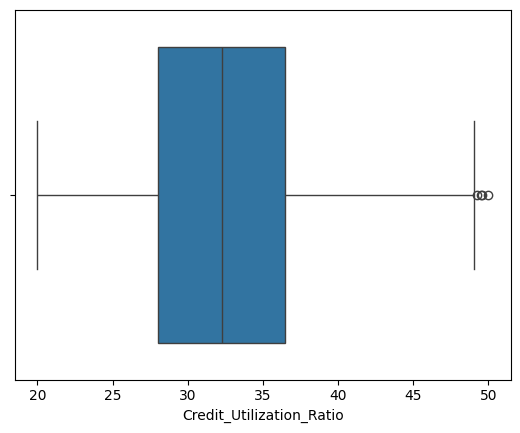

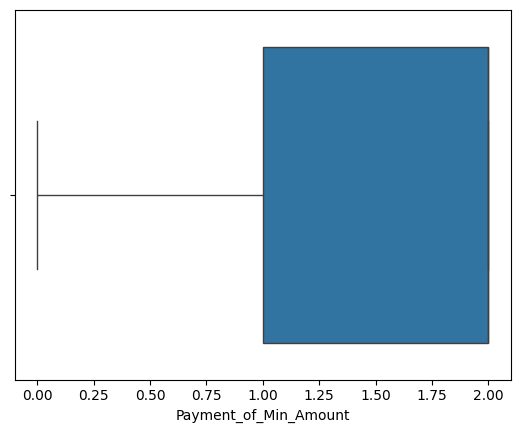

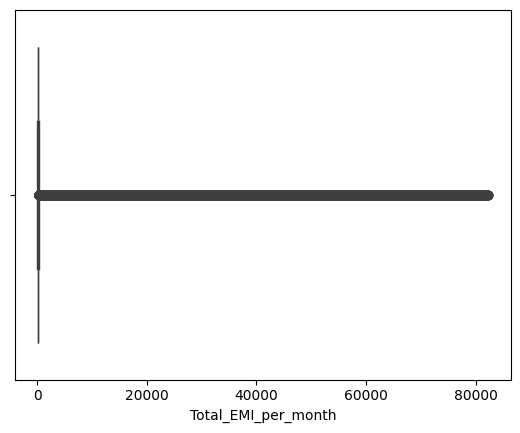

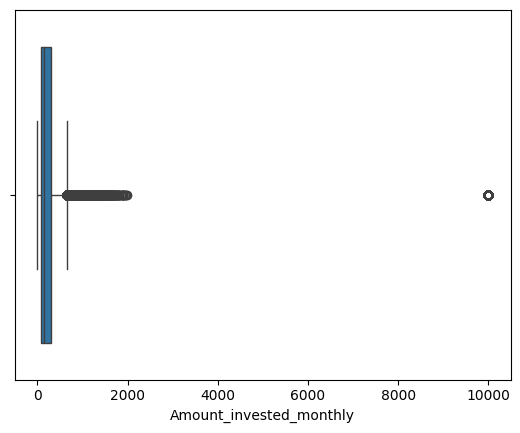

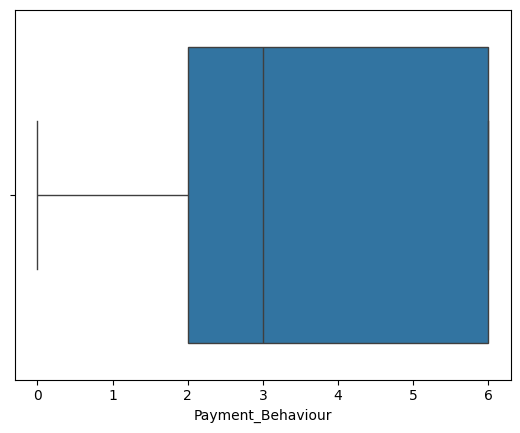

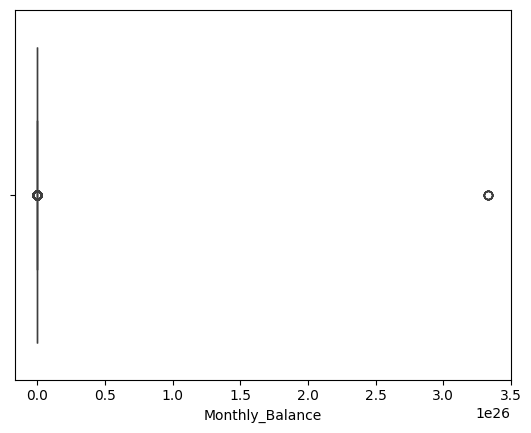

In [41]:
for i in data.columns:
  if data[i].dtypes != 'object' and data[i].nunique() > 2:
    sns.boxplot(data=data,x=data[i])
    plt.show()

In [42]:
q1 = data.quantile(0.25, numeric_only=True)
q3 = data.quantile(0.75, numeric_only=True)
iqr = q3-q1
upper = q3+ 1.5*iqr
lower= q1- 1.5*iqr

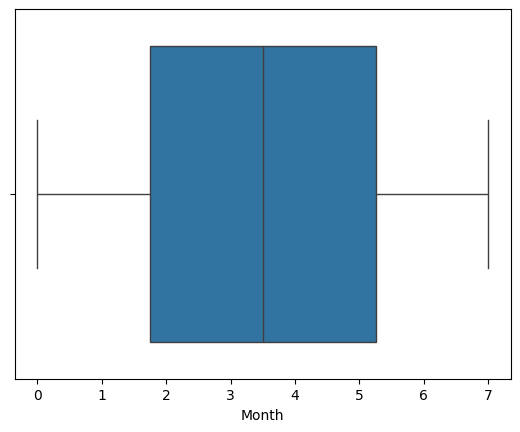

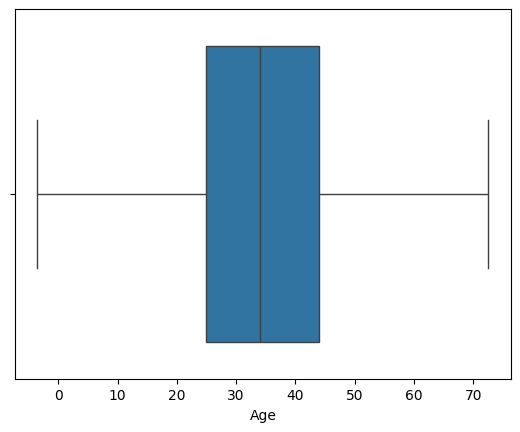

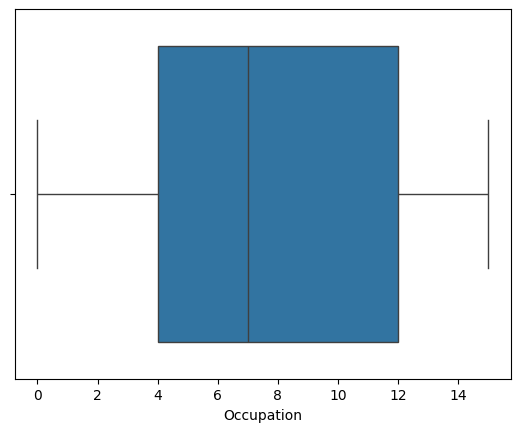

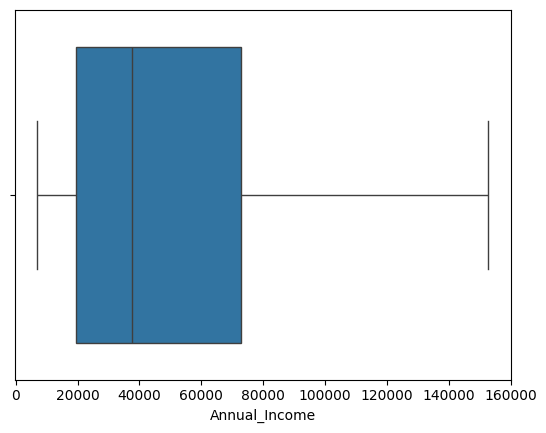

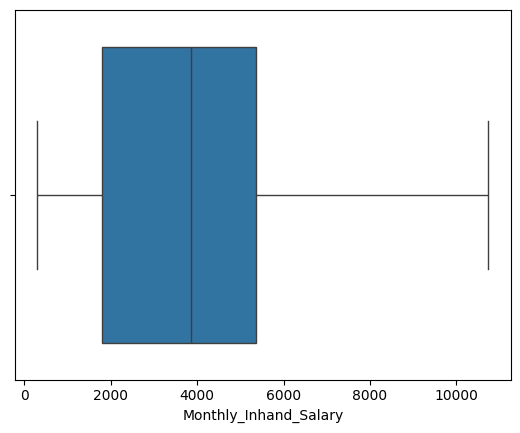

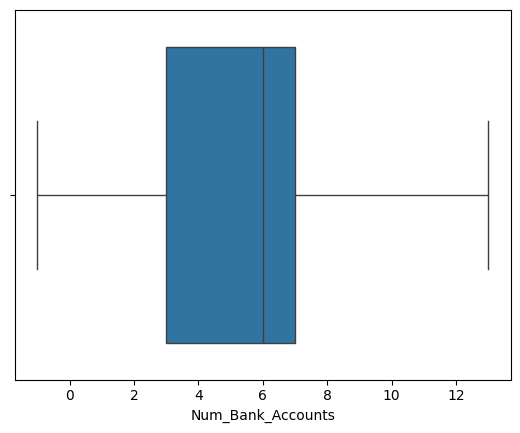

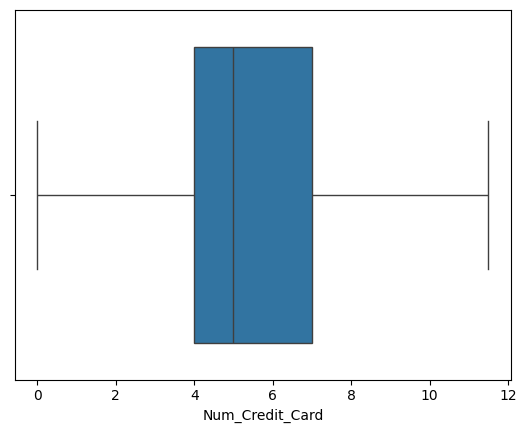

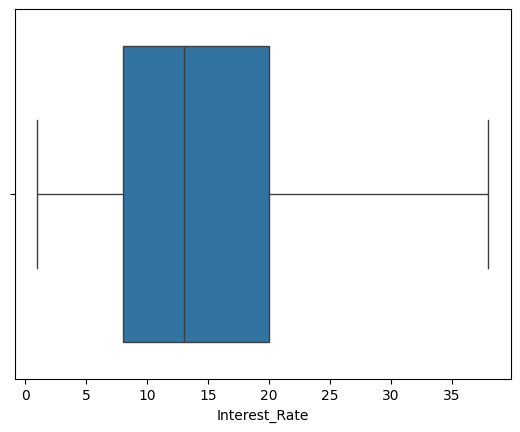

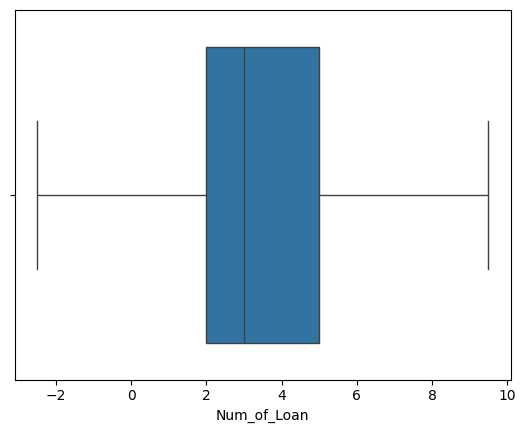

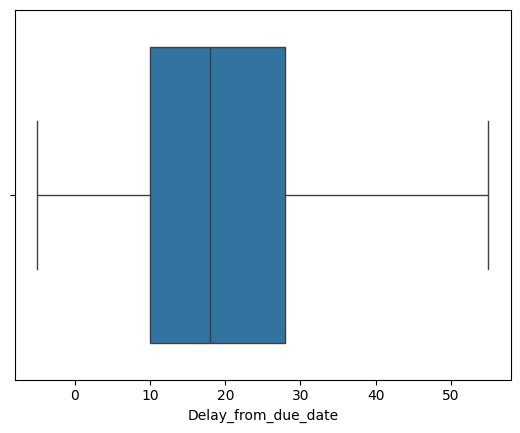

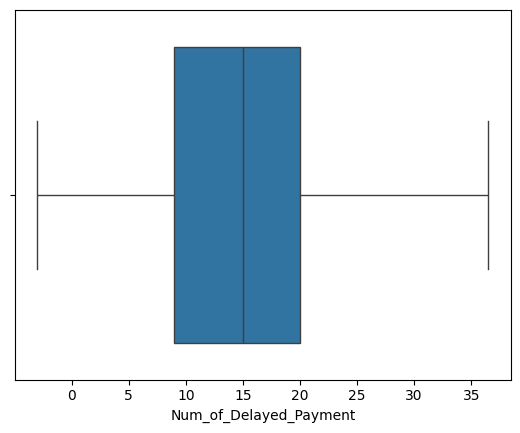

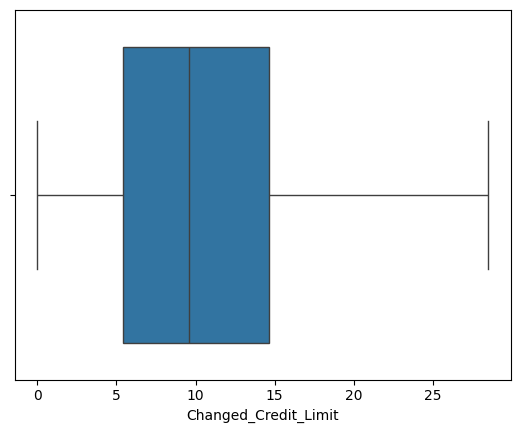

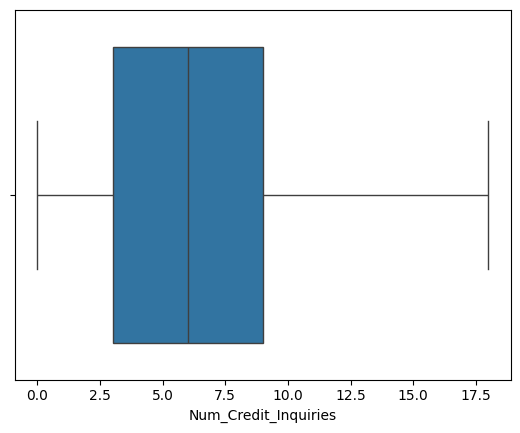

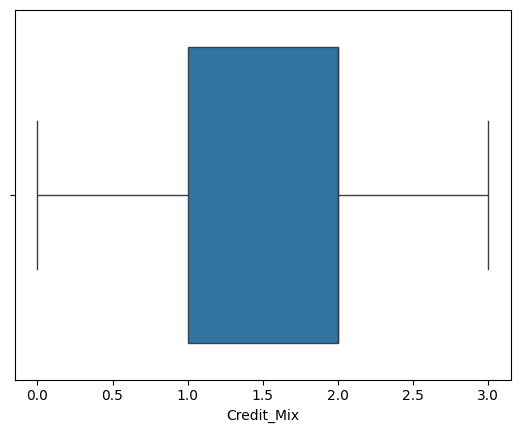

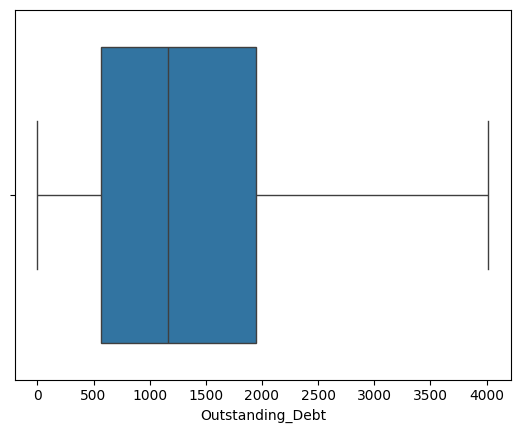

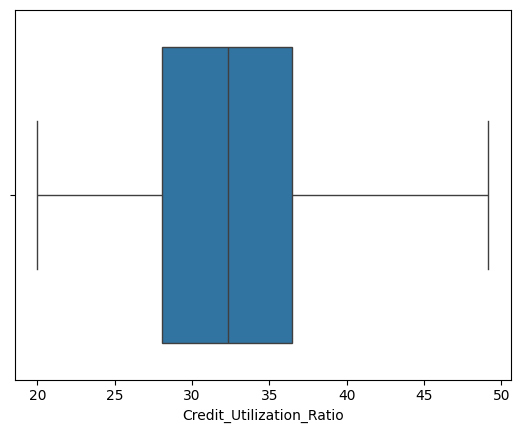

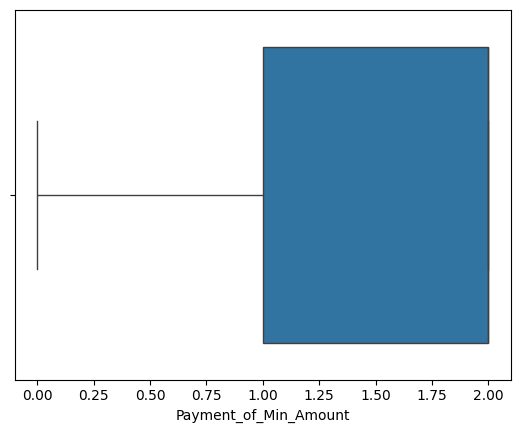

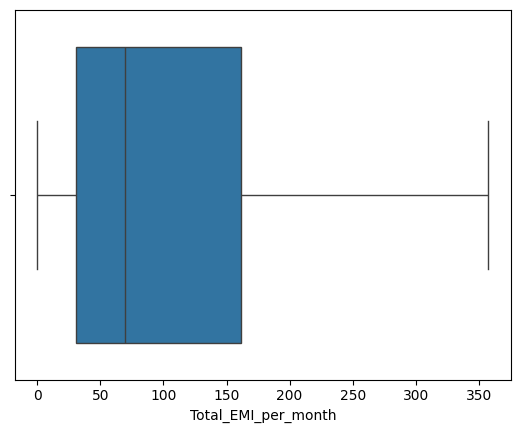

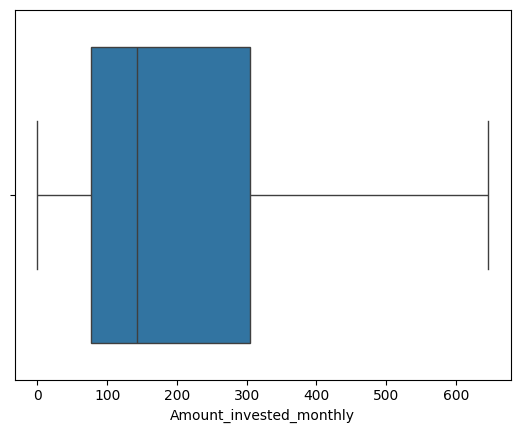

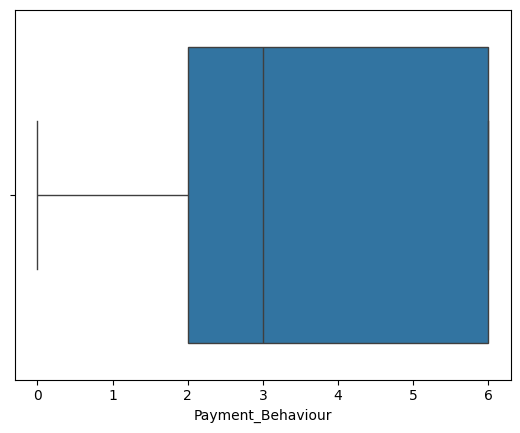

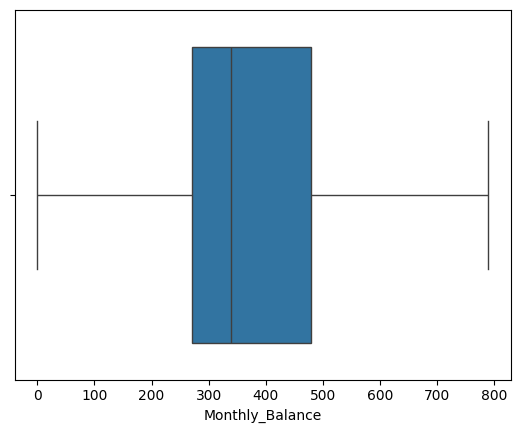

In [43]:
for i in data.columns:
  if data[i].dtypes != 'object' and data[i].nunique() > 2:
    data[i] = np.where(data[i]> upper[i], upper[i], data[i])
    data[i] = np.where(data[i]< lower[i], lower[i], data[i])
    sns.boxplot(data=data,x=data[i])
    plt.show()

In [44]:
inputs = data.drop('Credit_Score',axis=1)
target = data['Credit_Score']

## Scaling

In [45]:
sc = MinMaxScaler(feature_range=(0,1))
inputs_scaled = sc.fit_transform(inputs)

## SOM Hyperparameter Tuning (OPTUNA)

In [46]:
def objective(trial):

    x = trial.suggest_int("x", 10, 20)
    y = trial.suggest_int("y", 10, 20)
    sigma = trial.suggest_float("sigma", 0.1, 2.0, log=True)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    num_iteration = trial.suggest_int("num_iteration", 50, 500)


    som = MiniSom(x=x, y=y, input_len=inputs_scaled.shape[1], sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(inputs_scaled)
    som.train_random(data=inputs_scaled, num_iteration=num_iteration)


    labels = np.array([som.winner(x) for x in inputs_scaled])
    print(labels)

    flattened_labels = [i[0] * y + i[1] for i in labels]

    try:
        score = silhouette_score(inputs_scaled, flattened_labels)
    except ValueError:
        score = -1

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best parameters:", study.best_params)
print("Best silhouette score:", study.best_value)


[I 2026-06-09 07:38:50,541] A new study created in memory with name: no-name-a67dfb37-57de-4a60-a792-b48396cd1d5c


[[11  5]
 [ 0  8]
 [ 3  9]
 ...
 [ 3  7]
 [ 0  8]
 [ 6  9]]


[I 2026-06-09 07:40:19,416] Trial 0 finished with value: 0.014451635092312598 and parameters: {'x': 13, 'y': 12, 'sigma': 1.2213127841262175, 'learning_rate': 0.45962280428482605, 'num_iteration': 124}. Best is trial 0 with value: 0.014451635092312598.


[[17  8]
 [ 1  8]
 [14 10]
 ...
 [ 0  2]
 [ 0  1]
 [ 0 11]]


[I 2026-06-09 07:41:46,081] Trial 1 finished with value: 0.017117964241874534 and parameters: {'x': 19, 'y': 18, 'sigma': 1.7973882425552306, 'learning_rate': 0.04614665937874887, 'num_iteration': 345}. Best is trial 1 with value: 0.017117964241874534.


...

[[13  1]
 [12 11]
 [ 5  5]
 ...
 [ 1  5]
 [ 6 14]
 [12  8]]


[I 2026-06-09 07:51:47,697] Trial 8 finished with value: 0.01270920386460367 and parameters: {'x': 18, 'y': 15, 'sigma': 1.4336946765171437, 'learning_rate': 0.05947559887040059, 'num_iteration': 75}. Best is trial 7 with value: 0.020307740135228194.


[[5 9]
 [4 0]
 [5 1]
 ...
 [0 4]
 [4 0]
 [0 4]]


[I 2026-06-09 07:53:18,952] Trial 9 finished with value: 0.01653779033304706 and parameters: {'x': 11, 'y': 18, 'sigma': 0.5200296611029924, 'learning_rate': 0.08911511569639086, 'num_iteration': 349}. Best is trial 7 with value: 0.020307740135228194.


Best parameters: {'x': 10, 'y': 14, 'sigma': 0.42135169310132825, 'learning_rate': 0.5980574744846403, 'num_iteration': 349}
Best silhouette score: 0.020307740135228194


In [47]:
best_params = study.best_params
best_params

{'x': 10,
 'y': 14,
 'sigma': 0.42135169310132825,
 'learning_rate': 0.5980574744846403,
 'num_iteration': 349}

## Train final SOM model

In [48]:
som_opt = MiniSom(x=best_params['x'], y=best_params['y'], input_len=21,
              sigma=best_params['sigma'], learning_rate=best_params['learning_rate'])

som_opt.random_weights_init(inputs_scaled)

som_opt.train_random(data=inputs_scaled, num_iteration=best_params['num_iteration'])


## SOM vizualization

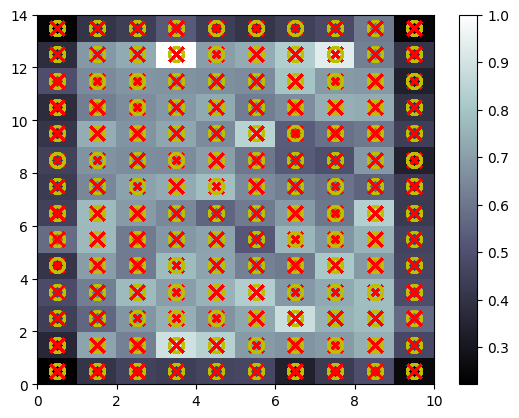

In [49]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
bone()
pcolor(som_opt.distance_map().T)
colorbar()
markers = ['x', 'o']
colors = ['r', 'y']

for i, x in enumerate(inputs_scaled):
    w = som_opt.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[target[i]],
         markeredgecolor=colors[target[i]],
         markerfacecolor='None',
         markersize=10,
         markeredgewidth=2)

show()

## Identify suspicious nodes
Nodes with distance >= 0.9 are potential fraud indicators

In [50]:
distance_map = som_opt.distance_map()

threshold = 0.9

white_nodes = [(i, j) for i in range(distance_map.shape[0]) for j in range(distance_map.shape[1]) if distance_map[i, j] >= threshold]

print("Positions of Nodes (Distance >= 0.9):")
for node in white_nodes:
  print(f"Node {node} - Distance: {distance_map[node[0], node[1]]:.2f}")


Positions of Nodes (Distance >= 0.9):
Node (3, 12) - Distance: 1.00
Node (7, 12) - Distance: 0.93


## Extract fraud canidates


In [51]:
mappings = som_opt.win_map(inputs_scaled)

frauds = []

for node in white_nodes:
    if node in mappings:
        fraud_data = mappings[node]
        frauds.append(fraud_data)

frauds = np.concatenate(frauds, axis=0)

frauds = sc.inverse_transform(frauds)

frauds

array([[  5.        ,  21.        ,  12.        , ..., 332.21004241,
          5.        ,  59.88619327],
       [  1.        ,  21.        ,  12.        , ..., 510.01476319,
          4.        , 790.08076347],
       [  6.        ,  21.        ,   0.        , ..., 637.41299841,
          1.        , 289.88785809],
       ...,
       [  2.        ,  21.        ,  12.        , ...,  85.14868131,
          6.        , 231.26269317],
       [  1.        ,  21.        ,  12.        , ...,  33.96708321,
          6.        , 282.44429127],
       [  0.        ,  17.        ,   1.        , ...,  58.40790577,
          6.        , 258.55202633]])

In [52]:
frauds_df = pd.DataFrame(frauds, columns=inputs.columns)

frauds_df

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,5.0,21.0,12.0,69977.600,4194.170850,10.0,7.0,20.0,9.000000,54.0,20.000000,6.810,11.0,0.0,3042.3600,28.130695,0.0,357.600632,332.210042,5.0,59.886193
1,1.0,21.0,12.0,69977.600,5978.466667,10.0,7.0,20.0,9.000000,49.0,18.000000,6.810,11.0,0.0,3042.3600,36.251111,0.0,357.600632,510.014763,4.0,790.080763
2,6.0,21.0,0.0,44719.170,3969.597500,6.0,6.0,29.0,7.000000,47.0,21.000000,23.210,11.0,0.0,3818.5700,27.979751,0.0,248.599886,637.412998,1.0,289.887858
3,3.0,42.0,15.0,57610.320,4194.170850,8.0,10.0,25.0,9.000000,41.0,23.000000,21.310,7.0,0.0,4015.7975,40.457538,0.0,256.234179,646.387878,5.0,53.754384
4,7.0,26.0,9.0,77418.520,6450.543333,7.0,9.0,20.0,7.000000,38.0,24.000000,20.050,6.0,0.0,3962.0800,34.949404,0.0,339.031032,135.739846,1.0,410.283455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,0.0,14.0,11.0,28417.580,2365.131667,6.0,8.0,27.0,2.780339,39.0,31.033051,25.600,18.0,0.0,3131.4500,27.421268,2.0,125.357122,137.783478,6.0,263.372566
342,0.0,21.0,12.0,34458.060,3142.505000,9.0,10.0,29.0,5.000000,17.0,16.000000,23.590,11.0,0.0,4015.7975,35.273431,2.0,357.600632,142.370145,6.0,342.257898
343,2.0,21.0,12.0,10498.770,4194.170850,9.0,6.0,29.0,6.000000,15.0,25.000000,27.560,10.0,0.0,4015.7975,26.673121,2.0,41.078376,85.148681,6.0,231.262693
344,1.0,21.0,12.0,10498.770,674.897500,9.0,6.0,29.0,6.000000,15.0,25.000000,27.560,10.0,0.0,4015.7975,29.310801,2.0,41.078376,33.967083,6.0,282.444291


In [53]:
common_cols = list(set(data.columns) & set(frauds_df.columns))

common_cols

['Payment_Behaviour',
 'Total_EMI_per_month',
 'Monthly_Inhand_Salary',
 'Num_Credit_Inquiries',
 'Monthly_Balance',
 'Credit_Utilization_Ratio',
 'Amount_invested_monthly',
 'Age',
 'Month',
 'Outstanding_Debt',
 'Delay_from_due_date',
 'Changed_Credit_Limit',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Card',
 'Annual_Income',
 'Interest_Rate',
 'Payment_of_Min_Amount',
 'Occupation',
 'Credit_Mix',
 'Num_Bank_Accounts']

## Label Fraud in main dataset

In [32]:
data_ = data.merge(frauds_df[common_cols].assign(is_fraud=1), how="left", on=common_cols)

data_

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,is_fraud
0,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.000000,11.270000,4.0,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089,0,NaN
1,2.0,23.0,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,-1.0,31.033051,11.270000,4.0,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162,0,NaN
2,6.0,-3.5,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,3.0,7.000000,10.465678,4.0,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863,0,NaN
3,0.0,23.0,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,5.0,4.000000,6.270000,4.0,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310,0,NaN
4,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,31.033051,11.270000,4.0,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,23.0,7.000000,11.500000,3.0,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228,1,NaN
99996,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,18.0,7.000000,11.500000,3.0,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610,1,NaN
99997,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,27.0,6.000000,11.500000,3.0,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083,1,NaN
99998,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,20.0,31.033051,11.500000,3.0,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979,0,NaN


In [54]:
data_["is_fraud"] = np.where(data_["is_fraud"].isna(),0,1)

data_

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,is_fraud
0,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.000000,11.270000,4.0,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089,0,0
1,2.0,23.0,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,-1.0,31.033051,11.270000,4.0,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162,0,0
2,6.0,-3.5,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,3.0,7.000000,10.465678,4.0,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863,0,0
3,0.0,23.0,12.0,19114.12,4194.170850,3.0,4.0,3.0,4.0,5.0,4.000000,6.270000,4.0,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310,0,0
4,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,31.033051,11.270000,4.0,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,23.0,7.000000,11.500000,3.0,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228,1,0
99996,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,18.0,7.000000,11.500000,3.0,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610,1,0
99997,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,27.0,6.000000,11.500000,3.0,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083,1,0
99998,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,20.0,31.033051,11.500000,3.0,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979,0,0


## Prepare ANN inputs

In [55]:
targets = data_['is_fraud']

inputs = data_.drop(['is_fraud'],axis=1)

In [56]:
inputs.columns

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score'],
      dtype='object')

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,-0.218218,-0.856761,0.964732,-0.830797,-0.840256,-0.907532,-0.748691,-1.296440,0.268348,-1.240483,-1.006947,0.125158,-0.502493,1.402073,-0.543073,-1.067570,-0.58149,-0.559441,-0.720066,-0.230434,-0.449771,-0.639070
1,-0.654654,-0.856761,0.964732,-0.830797,0.026406,-0.907532,-0.748691,-1.296440,0.268348,-1.517738,1.939841,0.125158,-0.502493,-0.571010,-0.543073,-0.066486,-0.58149,-0.559441,-0.532179,0.260855,-0.602359,-0.639070
2,1.091089,-2.654026,0.964732,-0.830797,0.026406,-0.907532,-0.748691,-1.296440,0.268348,-1.240483,-1.006947,0.002424,-0.502493,-0.571010,-0.543073,-0.718380,-0.58149,-0.559441,-0.713694,0.752144,-0.347284,-0.639070
3,-1.527525,-0.856761,0.964732,-0.830797,0.026406,-0.907532,-0.748691,-1.296440,0.268348,-1.101856,-1.374789,-0.637806,-0.502493,-0.571010,-0.543073,-0.177317,-0.58149,-0.559441,-0.129370,1.243433,-0.937368,-0.639070
4,1.527525,-0.856761,0.964732,-0.830797,-0.840256,-0.907532,-0.748691,-1.296440,0.268348,-1.032542,1.939841,0.125158,-0.502493,-0.571010,-0.543073,-1.463379,-0.58149,-0.559441,-0.913562,-0.721723,-0.290994,-0.639070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-1.527525,-0.721119,0.318218,-0.300487,-0.278934,-0.539811,0.148576,-0.864616,-0.488504,0.145792,-1.006947,0.160255,-0.728553,1.402073,-0.826266,0.464826,-0.58149,-0.697878,-0.816548,-1.213013,0.466756,1.564773
99996,1.527525,-0.721119,0.318218,-0.300487,-0.278934,-0.539811,0.148576,-0.864616,-0.488504,-0.200777,-1.006947,0.160255,-0.728553,1.402073,-0.826266,1.618294,-0.58149,-0.697878,-0.850218,-0.721723,0.558673,1.564773
99997,0.654654,-0.721119,0.318218,-0.300487,-0.278934,-0.539811,0.148576,2.482026,-0.488504,0.423047,-1.129561,0.160255,-0.728553,-0.571010,-0.826266,1.753123,-0.58149,-0.697878,-0.999860,-1.213013,0.669055,1.564773
99998,0.218218,-0.721119,0.318218,-0.300487,-0.278934,-0.539811,0.148576,-0.864616,-0.488504,-0.062149,1.939841,0.160255,-0.728553,-0.571010,-0.826266,0.264434,-0.58149,-0.697878,0.129721,0.260855,-0.413242,-0.639070


## Train-Test split
80/20 split with stratify to preserve class balance

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42, stratify=targets )

In [59]:
pip install tensorflow

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam
from sklearn.metrics import roc_auc_score

## ANN model builer (OPTUNA)

In [68]:
def create_model(trial):
    model = Sequential()
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model

In [69]:
def optimal(trial):

    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    return auc

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=10)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-06-09 10:38:10,254] A new study created in memory with name: no-name-eacc5a07-5c83-4cf6-8bfc-6117ce0cfe45


Epoch 1/44


/tmp/ipykernel_8555/474456617.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


1667/1667 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.0390 - loss: 0.1334
Epoch 2/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - AUC: 0.1434 - loss: 0.0162
Epoch 3/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - AUC: 0.2769 - loss: 0.0079
Epoch 4/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.3570 - loss: 0.0051
Epoch 5/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4031 - loss: 0.0037
Epoch 6/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4304 - loss: 0.0030
Epoch 7/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4478 - loss: 0.0025
Epoch 8/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4591 - loss: 0.0021
Epoch 9/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4677 - loss: 0.0019
Epoch 10/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4738 - loss: 0.0017
Epoch 11/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - AUC: 0.4784 - loss: 0.0016
Epoch 12/44
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4820 - loss: 0.0014
Epoch 13/44


[I 2026-06-09 10:39:59,081] Trial 0 finished with value: 0.07315365768288418 and parameters: {'epochs': 44, 'batch_size': 48, 'units_layer1': 18, 'units_layer2': 26, 'optimizer': 'sgd', 'learning_rate': 0.002790624701158303}. Best is trial 0 with value: 0.07315365768288418.


...

Epoch 1/37


/tmp/ipykernel_8555/474456617.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5145 - loss: 0.0417
Epoch 2/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.5000 - loss: 6.4933e-04
Epoch 3/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 6.4768e-04
Epoch 4/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 6.4128e-04
Epoch 5/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 6.3464e-04
Epoch 6/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 6.2701e-04
Epoch 7/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 6.1736e-04
Epoch 8/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.5000 - loss: 5.8504e-04
Epoch 9/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.5000 - loss: 5.8257e-04
Epoch 10/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 5.6733e-04
Epoch 11/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.5000 - loss: 5.4876e-04
Epoch 12/37
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step -

[I 2026-06-09 10:55:28,824] Trial 9 finished with value: 0.984749237461873 and parameters: {'epochs': 37, 'batch_size': 64, 'units_layer1': 23, 'units_layer2': 25, 'optimizer': 'rmsprop', 'learning_rate': 0.0003118955224595311}. Best is trial 6 with value: 0.9988999449972499.


Best trial: 0.9988999449972499
Best hyperparameters: {'epochs': 16, 'batch_size': 52, 'units_layer1': 25, 'units_layer2': 7, 'optimizer': 'adam', 'learning_rate': 0.0009832685090279852}


## Best ANN parameters

In [70]:
best_params = study.best_trial.params

best_params

{'epochs': 16,
 'batch_size': 52,
 'units_layer1': 25,
 'units_layer2': 7,
 'optimizer': 'adam',
 'learning_rate': 0.0009832685090279852}

## Build final ANN model

In [71]:
best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='sigmoid'))

In [72]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])


In [73]:
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['AUC'])

## Evaluate model
Train and evaluate using Gini coefficient on train and test sets.
Gini = 2*AUC - 1, standard metric in credit risk industry

In [74]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])

    '''Predictions and probabilities for the training set'''

    y_train_prob = model.predict(X_train)

    '''Predictions and probabilities for the test set'''

    y_test_prob = model.predict(X_test)

    '''Calculate metrics for the training set'''

    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1


    '''Calculate metrics for the test set'''

    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],

    })

    return results

In [75]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - AUC: 0.3964 - loss: 0.0226
Epoch 2/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4992 - loss: 6.4695e-04
Epoch 3/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.4996 - loss: 4.4244e-04
Epoch 4/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6662 - loss: 2.9606e-04
Epoch 5/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.6663 - loss: 2.6542e-04
Epoch 6/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.9999 - loss: 1.3504e-04
Epoch 7/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 1.0000 - loss: 6.6365e-05
Epoch 8/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 1.0000 - loss: 4.9978e-05
Epoch 9/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 1.0000 - loss: 2.5788e-05
Epoch 10/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 1.0000 - loss: 3.0944e-05
Epoch 11/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - AUC: 1.0000 - loss: 3.7059e-05
Epoch 12/16
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s

,Dataset,Gini
0,Train,100.000000
1,Test,99.979999


## Save best model
 Save trained model for deployment

In [76]:
best_model.save("som_ann_model.h5")

## Import Saved model

In [77]:
model = tf.keras.models.load_model("som_ann_model.h5")

model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_123 (Dense)               │ (None, 25)             │           575 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 7)              │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 767 (3.00 KB)

 Trainable params: 765 (2.99 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [80]:
data_dep= pd.read_excel(r'/content/test_practice.xlsx')

In [81]:
data_dep

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x32f5,1,41.0,10,48297.480,4194.170850,8,3.0,10,0.000000,16,16.000000,11.770000,2,2,1323.5400,39.267812,1,0.000000,66.383902,0,567.995098,0
1,CUS_0x6349,3,45.0,12,22555.520,1995.626667,6,3.0,14,4.000000,30,12.000000,6.790000,2,2,1418.4900,28.025400,1,55.007097,22.547178,1,362.008391,0
2,CUS_0x97a4,1,24.0,13,58942.600,5168.883333,9,6.0,18,6.000000,55,22.000000,0.520000,13,0,2517.0000,40.112470,0,187.703545,102.807719,1,466.377069,1
3,CUS_0x9a86,5,72.5,8,29827.360,2722.613333,4,5.0,17,2.000000,15,31.033051,10.560000,6,2,1872.7500,32.926459,2,31.496674,87.521193,2,403.243466,1
4,CUS_0x2c32,1,72.5,9,7823.985,599.998750,6,5.0,34,3.000000,55,25.000000,8.530000,11,0,2193.1100,28.337052,2,11.426858,32.454354,5,296.118663,1
5,CUS_0xb79c,5,19.0,1,72000.700,4194.170850,6,11.5,19,4.000000,19,12.000000,3.180000,1,2,68.4100,30.113676,1,325.034486,646.387878,6,4.388831,0
6,CUS_0x24a1,3,34.0,13,17200.970,1185.414167,8,9.0,27,4.000000,24,10.000000,7.300000,9,2,1513.2700,39.944538,2,48.513816,120.981325,6,239.046276,1
7,CUS_0x8b6c,6,72.5,6,17561.270,1561.439167,5,4.0,20,6.000000,27,18.000000,14.870000,5,2,2622.4400,24.147481,2,83.409787,646.387878,6,248.224668,0
8,CUS_0x638d,4,42.0,4,10629.930,1047.965648,6,7.0,15,1.000000,22,11.000000,11.150000,3,2,582.8300,35.723625,2,56.763698,45.711515,0,336.069389,0
9,CUS_0x9ef9,3,29.0,11,67188.580,5758.048333,5,7.0,9,3.000000,9,31.033051,3.840000,4,3,1370.9800,41.824996,1,145.929597,179.807959,2,500.067277,0


## Preprocessing deployment data

In [82]:
data_dep.describe(include='all')

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,50,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
unique,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUS_0x32f5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.760000,38.700000,8.220000,45935.997300,3914.614882,4.860000,5.770000,15.900000,3.391214,19.76000,14.221983,9.794914,5.840000,1.620000,1383.703200,32.643096,1.440000,88.229982,248.557497,3.700000,377.283423,0.240000
std,NaN,2.420659,16.542462,4.696025,39591.025892,3087.892797,2.449573,2.755718,10.608526,2.022547,14.63231,7.295387,5.894592,4.137238,0.966585,1117.364738,5.264786,0.674915,91.845530,238.735518,2.206206,177.209756,0.431419
min,NaN,0.000000,14.000000,0.000000,7621.800000,599.998750,0.000000,1.000000,3.000000,0.000000,-1.00000,0.000000,0.520000,0.000000,0.000000,19.940000,23.531461,0.000000,0.000000,22.547178,0.000000,4.388831,0.000000
25%,NaN,1.250000,24.750000,5.000000,15624.435000,1191.793854,3.000000,4.000000,8.250000,2.000000,9.00000,10.250000,6.110000,3.000000,1.000000,531.385000,28.476918,1.000000,28.591192,74.155076,2.000000,269.313170,0.000000
50%,NaN,4.000000,35.500000,8.000000,29722.040000,2908.921667,5.000000,5.000000,12.500000,3.000000,15.00000,13.000000,8.510000,5.000000,2.000000,1213.945000,32.880917,2.000000,53.714577,125.712064,4.000000,316.975698,0.000000
75%,NaN,6.000000,48.750000,12.750000,69238.130000,5665.866667,6.000000,7.000000,23.750000,4.000000,26.75000,18.000000,11.510000,8.000000,2.000000,1725.085000,35.954569,2.000000,103.305903,464.017903,6.000000,473.714898,0.000000


In [83]:
dt_dep =data_dep.copy()

In [84]:
dt_dep.drop(['Customer_ID'], axis=1, inplace=True)

In [85]:
dt_dep.isnull().sum()

,0
Month,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0


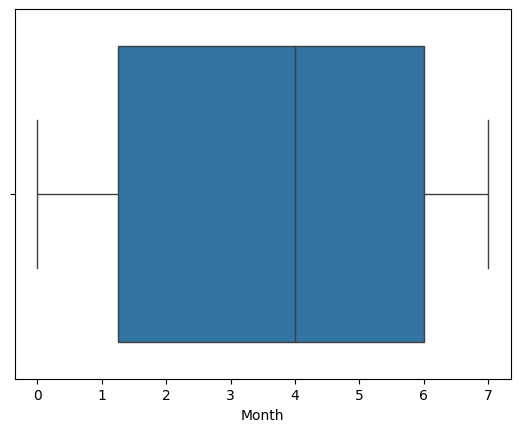

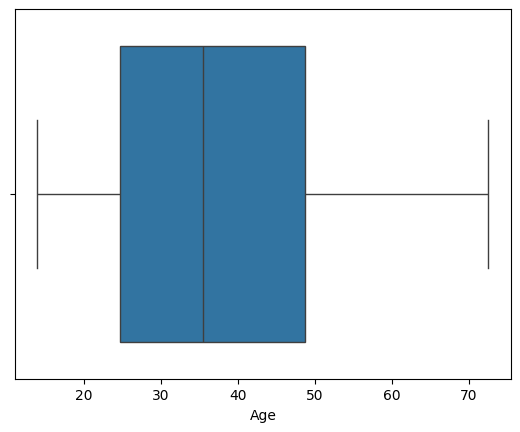

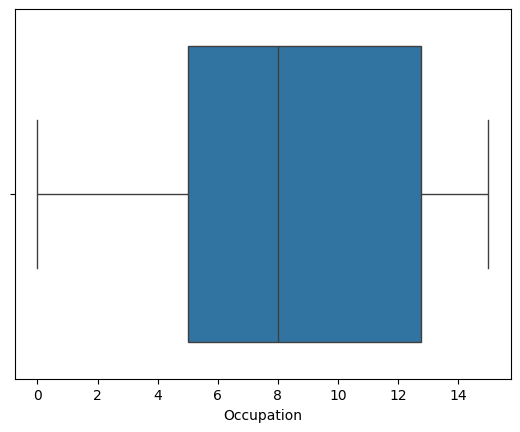

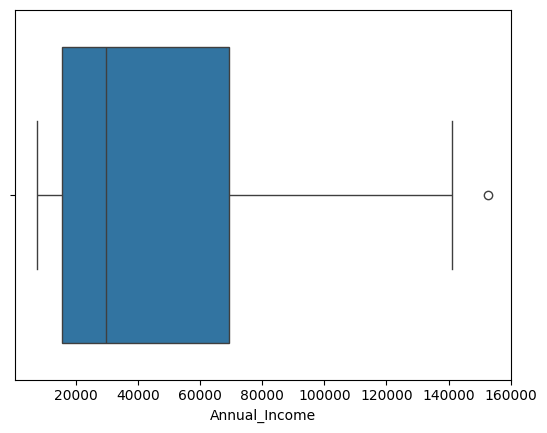

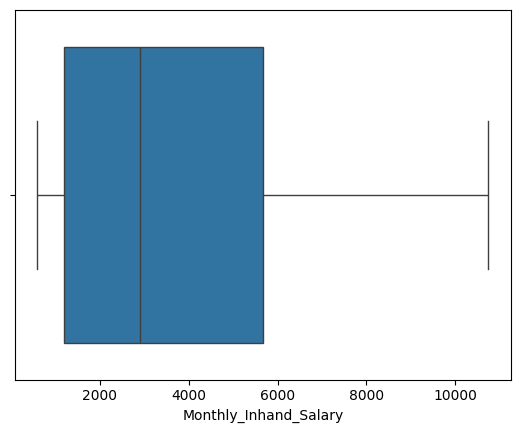

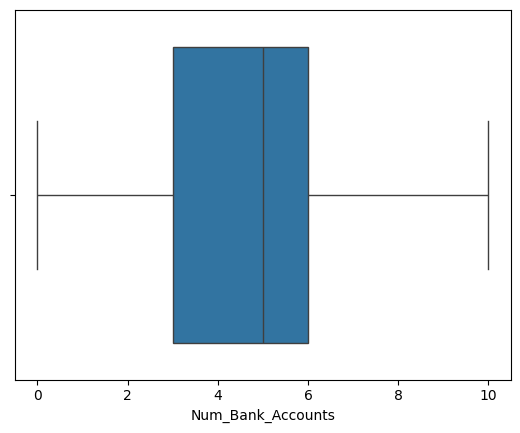

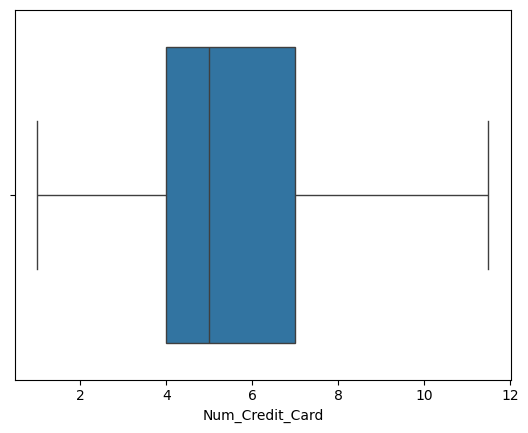

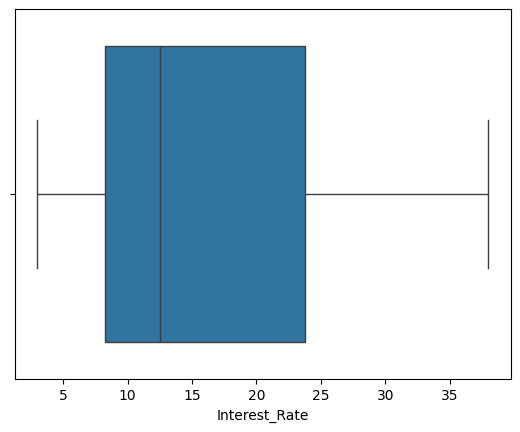

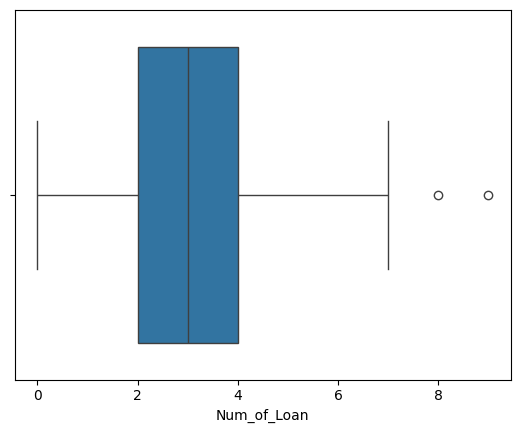

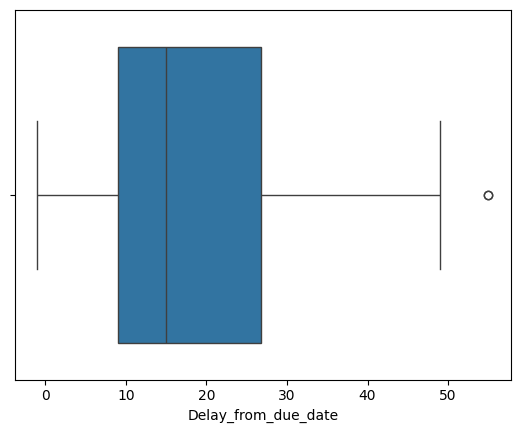

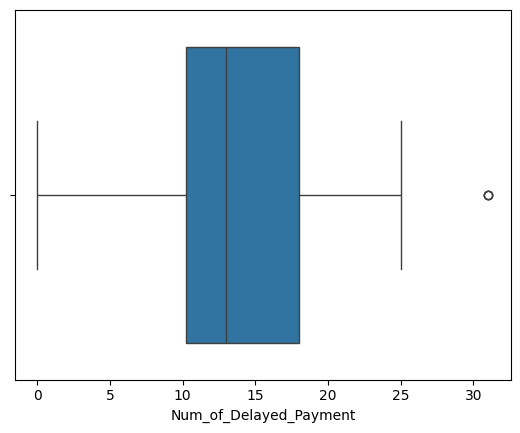

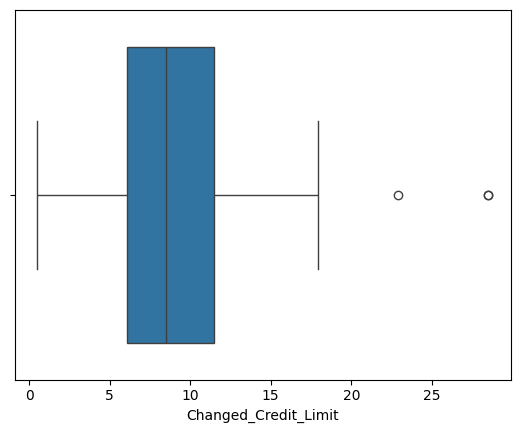

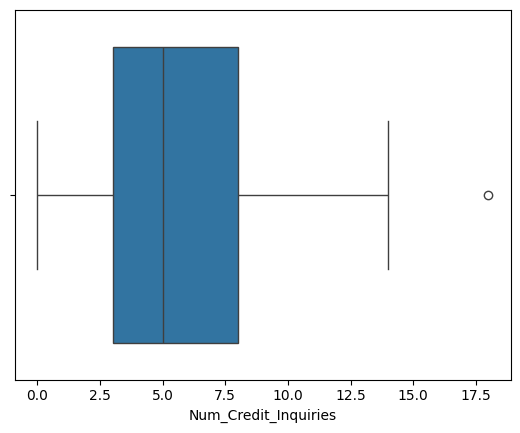

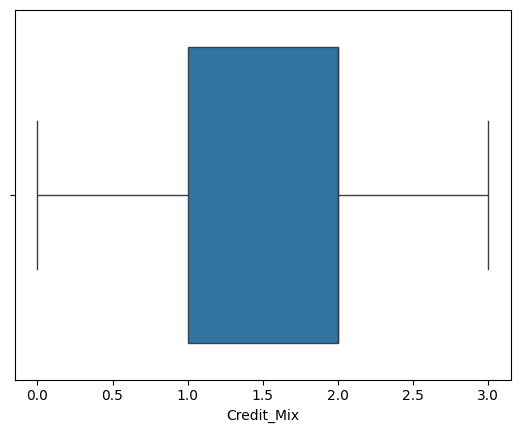

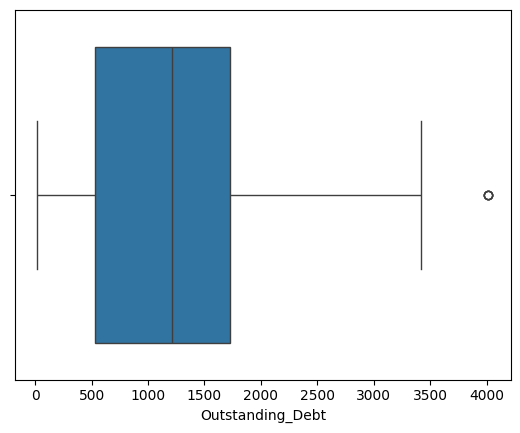

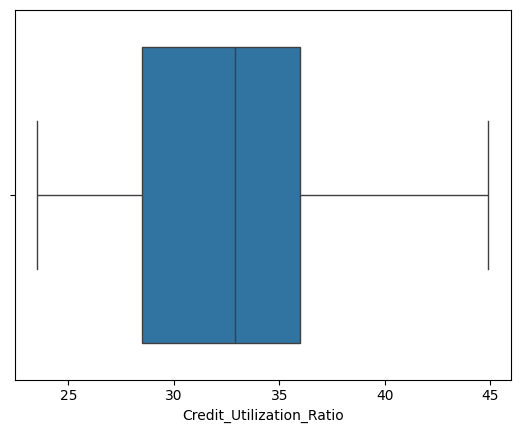

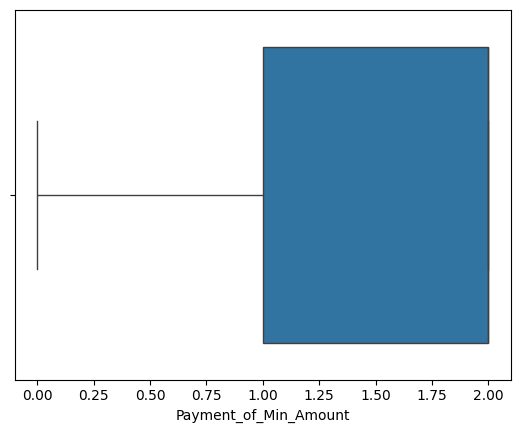

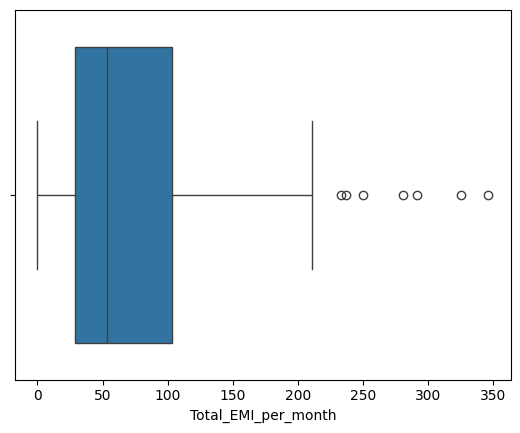

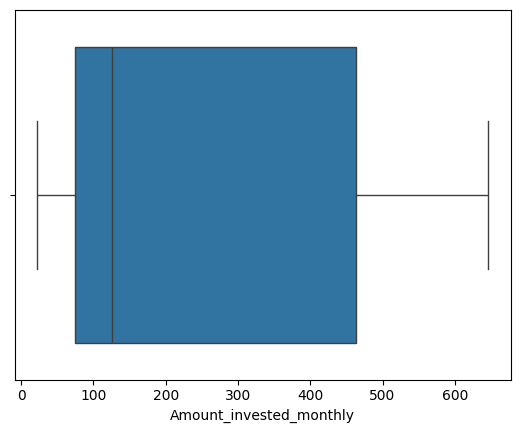

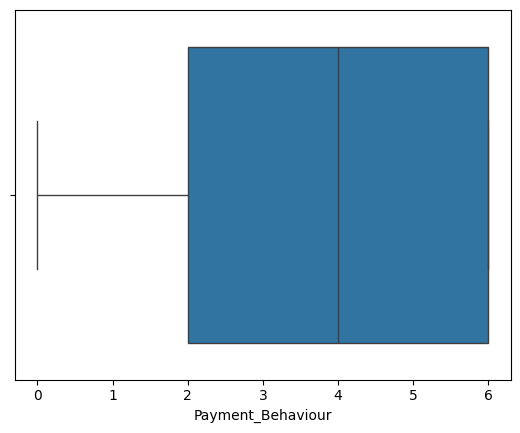

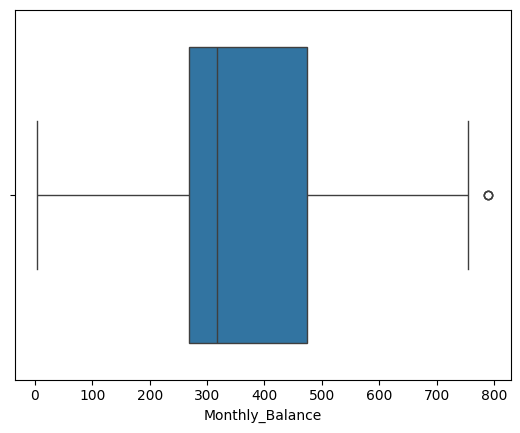

In [86]:
for i in dt_dep.columns:
  if dt_dep[i].dtypes != 'object' and dt_dep[i].nunique() > 2:
    sns.boxplot(data=dt_dep,x=dt_dep[i])
    plt.show()

In [87]:
q1 = dt_dep.quantile(0.25, numeric_only=True)
q3 = dt_dep.quantile(0.75, numeric_only=True)
iqr = q3-q1
upper = q3+ 1.5*iqr
lower= q1- 1.5*iqr

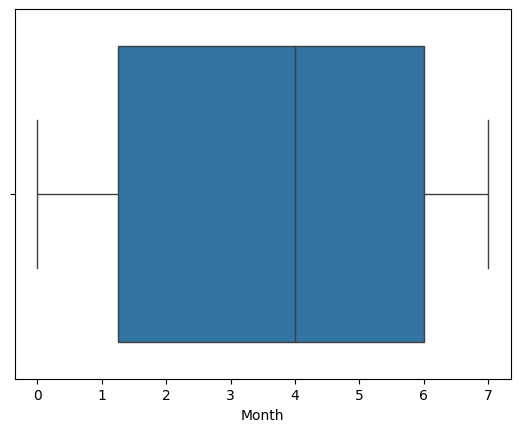

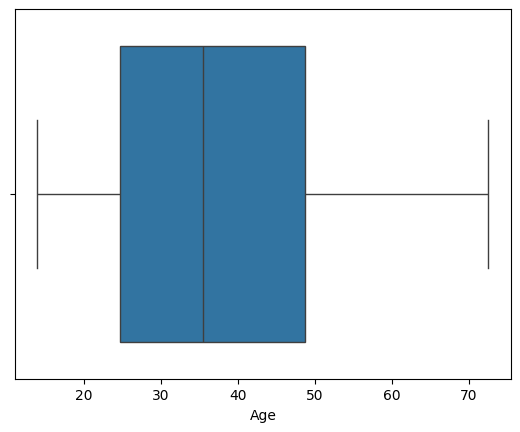

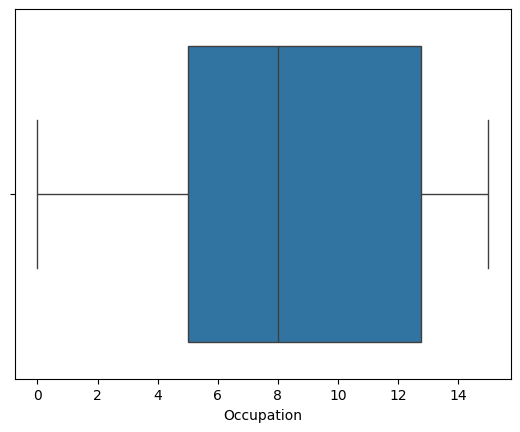

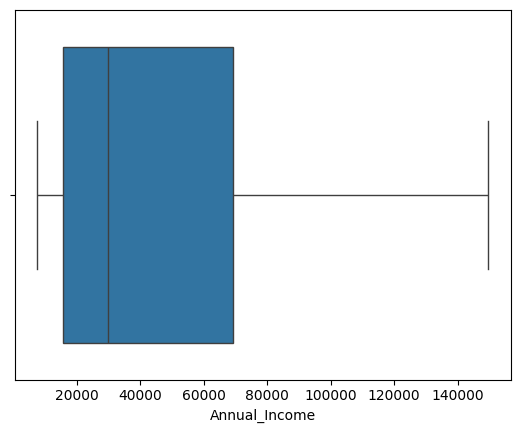

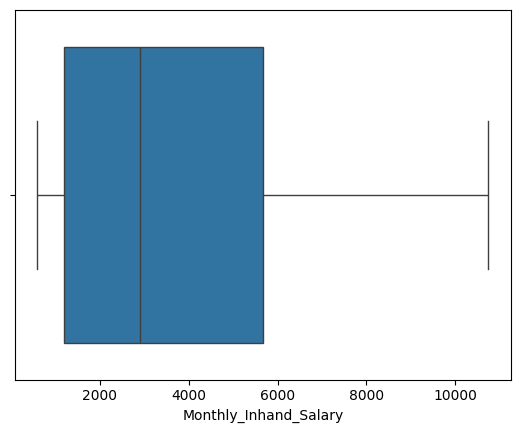

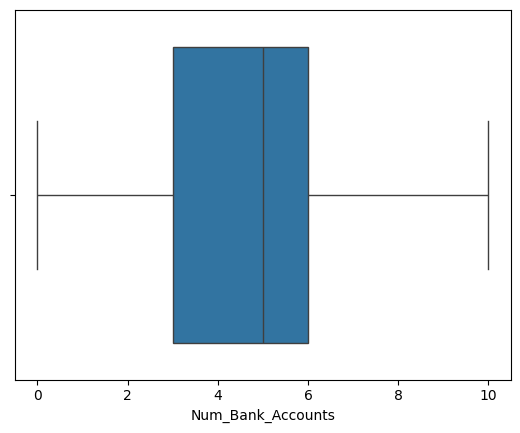

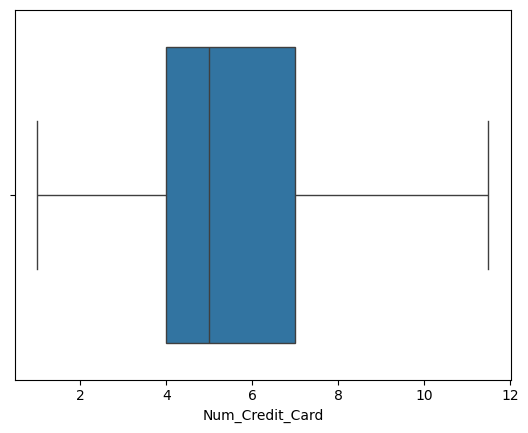

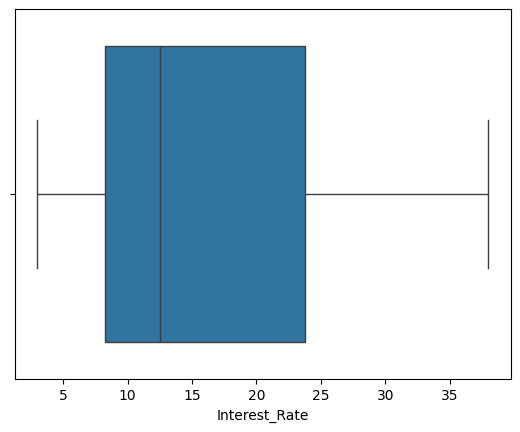

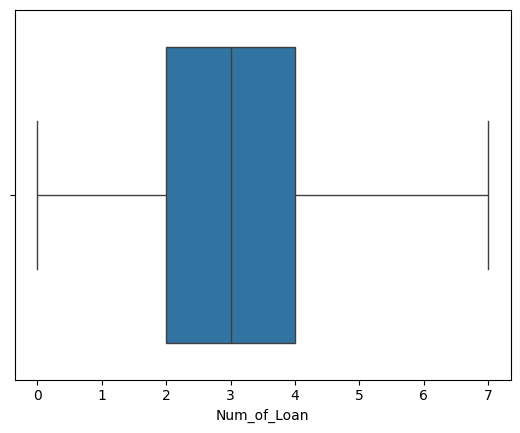

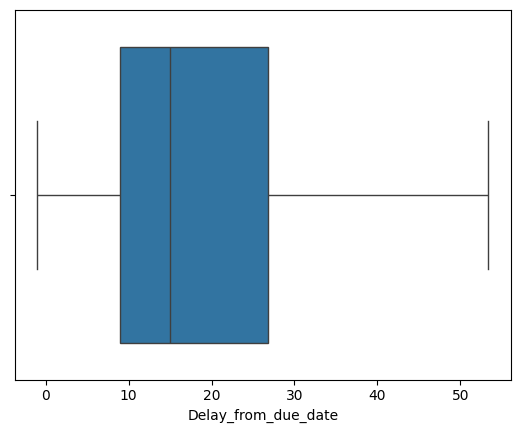

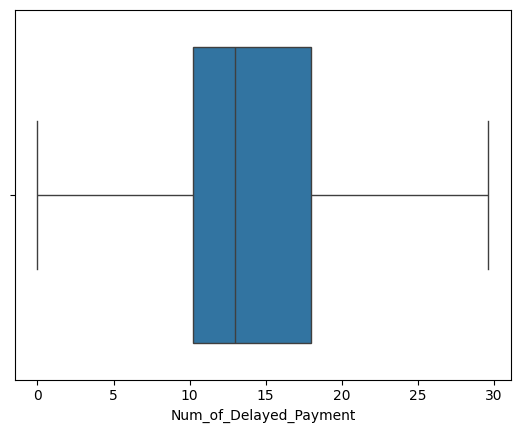

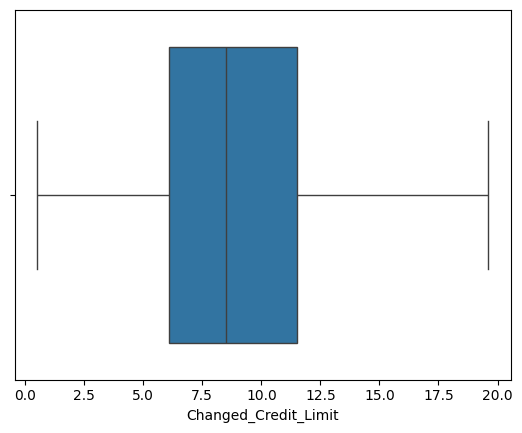

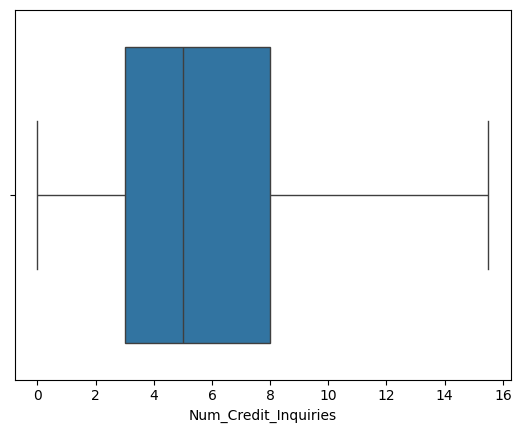

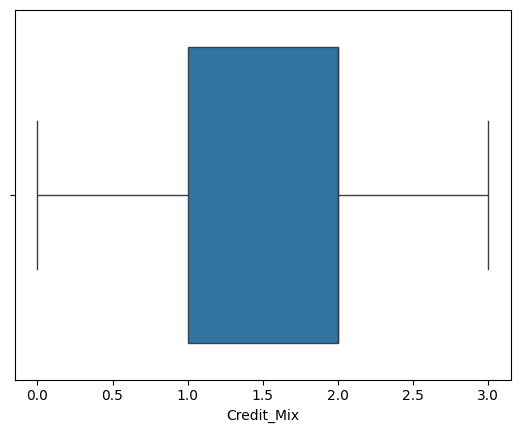

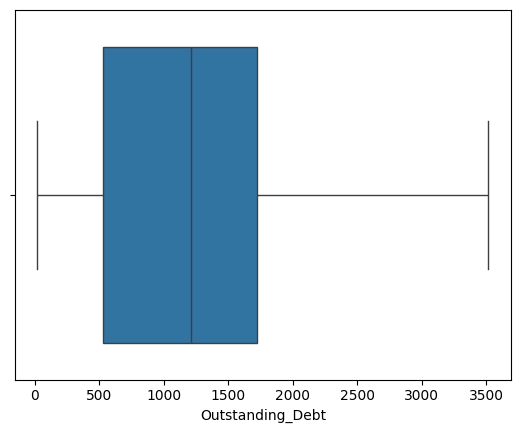

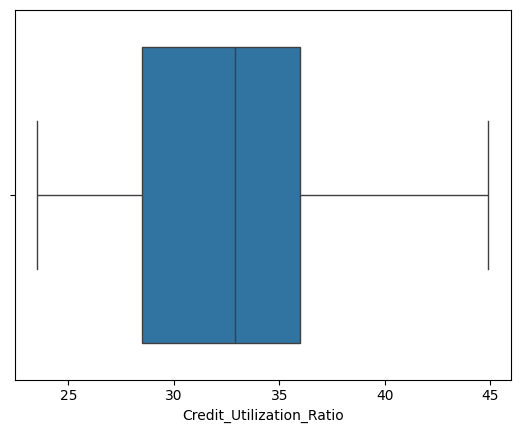

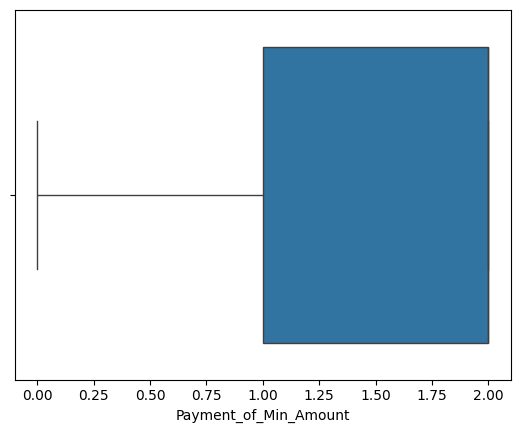

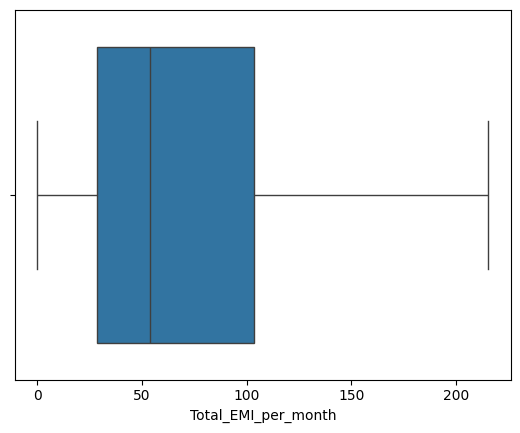

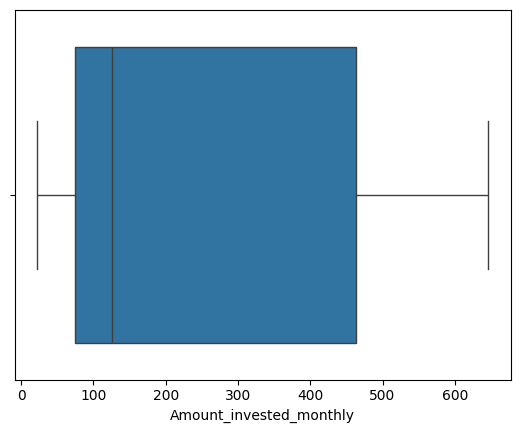

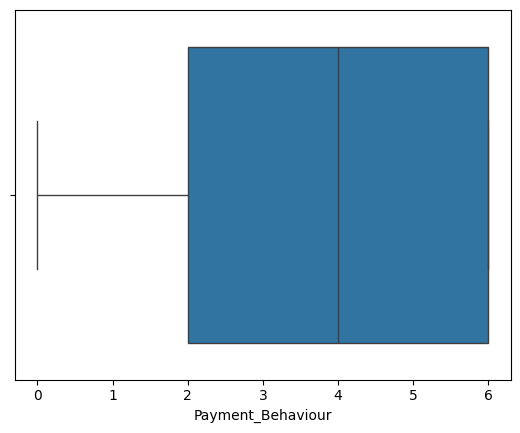

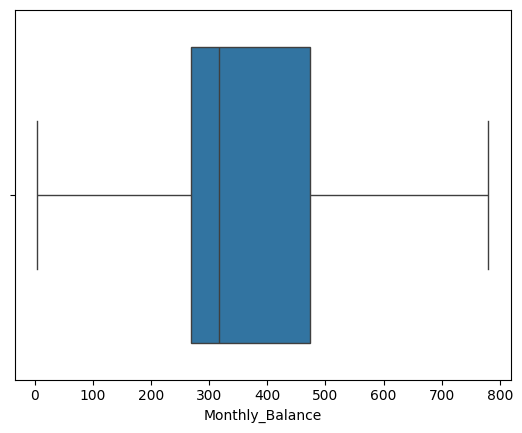

In [88]:
for i in dt_dep.columns:
  if dt_dep[i].dtypes != 'object' and dt_dep[i].nunique() > 2:
    dt_dep[i] = np.where(dt_dep[i]> upper[i], upper[i], dt_dep[i])
    dt_dep[i] = np.where(dt_dep[i]< lower[i], lower[i], dt_dep[i])
    sns.boxplot(data=dt_dep,x=dt_dep[i])
    plt.show()

In [89]:
scaled_test = scaler.transform(dt_dep.iloc[:,:])

test_scaled = pd.DataFrame(scaled_test, columns=dt_dep.iloc[:,:].columns)

test_scaled

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,-1.091089,0.364022,0.533723,-0.076407,0.026406,0.931074,-1.197324,-0.540747,-1.245356,-0.339404,0.096579,0.201455,-0.954613,0.415531,-0.070264,1.364655,-0.581490,-1.033701,-0.789691,-1.704302,0.949348,-0.639070
1,-0.218218,0.635308,0.964732,-0.741837,-0.777786,0.195631,-1.197324,-0.108922,0.268348,0.630988,-0.393877,-0.558458,-0.954613,0.415531,0.017152,-0.832505,-0.581490,-0.507475,-1.007211,-1.213013,-0.178632,-0.639070
2,-1.091089,-0.788940,1.180237,0.198769,0.382941,1.298795,0.148576,0.322902,1.025199,2.251197,0.832263,-1.515216,1.532048,-1.557552,1.028496,1.529731,-2.023712,0.761968,-0.608954,-1.213013,0.392890,1.564773
3,0.654654,2.500394,0.102714,-0.553860,-0.511866,-0.539811,-0.300057,0.214946,-0.488504,-0.408718,1.767194,0.016817,-0.050373,0.415531,0.435367,0.125333,0.860733,-0.732387,-0.684806,-0.721723,0.047171,1.564773
4,-1.091089,2.500394,0.318218,-1.122647,-1.288285,0.195631,-0.300057,2.050201,-0.110078,2.251197,1.200105,-0.292946,1.079928,-1.557552,0.730306,-0.771597,0.860733,-0.924386,-0.958051,0.752144,-0.539443,1.564773
5,0.654654,-1.128047,-1.405818,0.536321,0.026406,0.195631,2.616060,0.430858,0.268348,-0.131463,-0.393877,-1.109319,-1.180674,0.415531,-1.225800,-0.424383,-0.581490,1.026716,2.088318,1.243433,-2.136951,-0.639070
6,-0.218218,-0.110727,1.180237,-0.880252,-1.074149,0.931074,1.494477,1.294508,0.268348,0.215105,-0.639105,-0.480636,0.627807,0.415531,0.104411,1.496911,0.860733,-0.569593,-0.518776,1.243433,-0.851971,1.564773
7,1.091089,2.500394,-0.328295,-0.870938,-0.936605,-0.172090,-0.748691,0.538815,1.025199,0.423047,0.341807,0.674493,-0.276433,0.415531,1.125569,-1.590386,0.860733,-0.235760,2.088318,1.243433,-0.801710,-0.639070
8,0.218218,0.431844,-0.759304,-1.050113,-1.124426,0.195631,0.597210,-0.000966,-0.866930,0.076478,-0.516491,0.106847,-0.728553,0.415531,-0.752199,0.671997,0.860733,-0.490670,-0.892268,-1.704302,-0.320673,-0.639070
9,-0.218218,-0.449833,0.749227,0.411928,0.598448,-0.172090,0.597210,-0.648703,-0.110078,-0.824601,1.767194,-1.008607,-0.502493,1.402073,-0.026588,1.864418,-0.581490,0.362337,-0.226875,-0.721723,0.577377,-0.639070


## Predict Fraud probability

In [91]:
data_dep['prediction'] = model.predict(test_scaled)

data_dep

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,prediction
0,CUS_0x32f5,1,41.0,10,48297.480,4194.170850,8,3.0,10,0.000000,16,16.000000,11.770000,2,2,1323.5400,39.267812,1,0.000000,66.383902,0,567.995098,0,5.815329e-16
1,CUS_0x6349,3,45.0,12,22555.520,1995.626667,6,3.0,14,4.000000,30,12.000000,6.790000,2,2,1418.4900,28.025400,1,55.007097,22.547178,1,362.008391,0,8.992999e-13
2,CUS_0x97a4,1,24.0,13,58942.600,5168.883333,9,6.0,18,6.000000,55,22.000000,0.520000,13,0,2517.0000,40.112470,0,187.703545,102.807719,1,466.377069,1,4.169910e-15
3,CUS_0x9a86,5,72.5,8,29827.360,2722.613333,4,5.0,17,2.000000,15,31.033051,10.560000,6,2,1872.7500,32.926459,2,31.496674,87.521193,2,403.243466,1,3.210706e-10
4,CUS_0x2c32,1,72.5,9,7823.985,599.998750,6,5.0,34,3.000000,55,25.000000,8.530000,11,0,2193.1100,28.337052,2,11.426858,32.454354,5,296.118663,1,1.139259e-12
5,CUS_0xb79c,5,19.0,1,72000.700,4194.170850,6,11.5,19,4.000000,19,12.000000,3.180000,1,2,68.4100,30.113676,1,325.034486,646.387878,6,4.388831,0,1.362361e-16
6,CUS_0x24a1,3,34.0,13,17200.970,1185.414167,8,9.0,27,4.000000,24,10.000000,7.300000,9,2,1513.2700,39.944538,2,48.513816,120.981325,6,239.046276,1,8.466459e-11
7,CUS_0x8b6c,6,72.5,6,17561.270,1561.439167,5,4.0,20,6.000000,27,18.000000,14.870000,5,2,2622.4400,24.147481,2,83.409787,646.387878,6,248.224668,0,9.086422e-19
8,CUS_0x638d,4,42.0,4,10629.930,1047.965648,6,7.0,15,1.000000,22,11.000000,11.150000,3,2,582.8300,35.723625,2,56.763698,45.711515,0,336.069389,0,4.005270e-16
9,CUS_0x9ef9,3,29.0,11,67188.580,5758.048333,5,7.0,9,3.000000,9,31.033051,3.840000,4,3,1370.9800,41.824996,1,145.929597,179.807959,2,500.067277,0,6.161730e-11
